In [1]:
# ============================================================
# PART 3 — FEATURE ENGINEERING
# ============================================================
import os
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from shapely.geometry import Point
from shapely.ops import unary_union
import warnings
warnings.filterwarnings('ignore')

# Paths
BASE         = "/Users/riteshghorpade/Documents/010_Project/002_Dataset"
SEPA_PATH    = f"{BASE}/001_SEPA/GeoPackage/Data/PVAv2.gpkg"
OSM_BUILD    = f"{BASE}/002_OSM/osm_buildings_glasgow.gpkg"
OSM_ROADS    = f"{BASE}/002_OSM/osm_roads_glasgow.gpkg"
OSM_WATER    = f"{BASE}/002_OSM/osm_water_glasgow.gpkg"
NASA_ELEV    = f"{BASE}/003_NASA/nasa_elevation_glasgow.gpkg"
RAIN_DERIVED = f"{BASE}/003_NASA/hadukgrid_derived_features.csv"
MAPS_PATH    = f"{BASE}/004_Maps"
FEATURE_CSV  = f"{BASE}/feature_matrix.csv"

# Study area
UNI_X, UNI_Y, RADIUS = 260983, 665006, 5000
uni_point  = Point(UNI_X, UNI_Y)
uni_buffer = gpd.GeoDataFrame(
    geometry=[uni_point.buffer(RADIUS)], crs="EPSG:27700"
)

print("Ready!")

Ready!


In [2]:
# ============================================================
# CARE PROJECT — FEATURE ENGINEERING
# Climate Awareness and Risk Evaluation Dashboard
# ============================================================
# Student:    Ritesh Raju Ghorpade (202559288)
# Supervisor: Dr Daniel Thomas
# Deadline:   17th August 2026, noon UK time
# ============================================================
# Goal: Create a 7,843-point ML training dataset with
#       7 features and a 3-class flood risk label
# ============================================================

import os
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from shapely.geometry import Point
from shapely.ops import unary_union
import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded!")

Libraries loaded!


In [3]:
# ── File paths ──────────────────────────────────────────────
BASE         = "/Users/riteshghorpade/Documents/010_Project/002_Dataset"
SEPA_PATH    = f"{BASE}/001_SEPA/GeoPackage/Data/PVAv2.gpkg"
OSM_BUILD    = f"{BASE}/002_OSM/osm_buildings_glasgow.gpkg"
OSM_ROADS    = f"{BASE}/002_OSM/osm_roads_glasgow.gpkg"
OSM_WATER    = f"{BASE}/002_OSM/osm_water_glasgow.gpkg"
NASA_ELEV    = f"{BASE}/003_NASA/nasa_elevation_glasgow.gpkg"
RAIN_DERIVED = f"{BASE}/003_NASA/hadukgrid_derived_features.csv"
MAPS_PATH    = f"{BASE}/004_Maps"
FEATURE_CSV  = f"{BASE}/feature_matrix.csv"

# ── Study area ──────────────────────────────────────────────
UNI_X, UNI_Y, RADIUS = 260983, 665006, 5000
GRID_SPACING = 100

uni_point  = Point(UNI_X, UNI_Y)
uni_buffer = gpd.GeoDataFrame(
    geometry=[uni_point.buffer(RADIUS)],
    crs="EPSG:27700"
)

print("Paths configured!")
print(f"Study area: {RADIUS/1000}km radius around University of Strathclyde")
print(f"Grid spacing: {GRID_SPACING}m")

Paths configured!
Study area: 5.0km radius around University of Strathclyde
Grid spacing: 100m


In [4]:
# ── Load all datasets ───────────────────────────────────────
print("Loading datasets...")

pva        = gpd.read_file(SEPA_PATH)
pva_glasgow = pva[pva.geometry.intersects(uni_point.buffer(RADIUS))].copy()
buildings  = gpd.read_file(OSM_BUILD)
roads      = gpd.read_file(OSM_ROADS)
water      = gpd.read_file(OSM_WATER)
elevation  = gpd.read_file(NASA_ELEV)
df_derived = pd.read_csv(RAIN_DERIVED)

print(f"  SEPA Glasgow:  {len(pva_glasgow)} zones")
print(f"  Buildings:     {len(buildings):,}")
print(f"  Roads:         {len(roads):,}")
print(f"  Water:         {len(water):,}")
print(f"  Elevation:     {len(elevation):,}")
print(f"  Rainfall:      {len(df_derived)} grid cells")
print("\nAll datasets loaded!")

Loading datasets...
  SEPA Glasgow:  7 zones
  Buildings:     55,638
  Roads:         38,218
  Water:         195
  Elevation:     259,200
  Rainfall:      4 grid cells

All datasets loaded!


In [6]:
# ── Step 1: Create 100m grid ────────────────────────────────
# Regular grid of points spaced 100m apart
# covering the 5km circle around the university
# Each point becomes one row in the ML training dataset

print("Creating 100m grid...")

x_coords = np.arange(UNI_X - RADIUS, UNI_X + RADIUS, GRID_SPACING)
y_coords = np.arange(UNI_Y - RADIUS, UNI_Y + RADIUS, GRID_SPACING)

grid_points = [Point(x, y) for x in x_coords for y in y_coords
               if Point(x, y).distance(uni_point) <= RADIUS]

grid = gpd.GeoDataFrame(
    {'grid_id': range(len(grid_points))},
    geometry=grid_points,
    crs="EPSG:27700"
)

print(f"Grid points created: {len(grid):,}")
print(f"Grid spacing: {GRID_SPACING}m")
print(f"Coverage: {RADIUS/1000}km radius")

Creating 100m grid...
Grid points created: 7,843
Grid spacing: 100m
Coverage: 5.0km radius


In [7]:
# ── Step 2: Attach elevation ────────────────────────────────
# For each grid point find the nearest NASA SRTM elevation
# using spatial nearest neighbour join

print("Attaching elevation...")

grid = gpd.sjoin_nearest(
    grid,
    elevation[['elevation', 'geometry']],
    how='left'
).drop(columns=['index_right'])

print(f"Nulls: {grid['elevation'].isnull().sum()}")
print(f"\nElevation stats:")
print(f"  Min:  {grid['elevation'].min():.0f}m")
print(f"  Max:  {grid['elevation'].max():.0f}m")
print(f"  Mean: {grid['elevation'].mean():.1f}m")

Attaching elevation...
Nulls: 0

Elevation stats:
  Min:  -15m
  Max:  127m
  Mean: 42.1m


In [8]:
# ── Step 3: Distance to nearest water body ──────────────────
# Merge all water polygons into one shape then
# calculate distance from each grid point to nearest edge

print("Calculating distance to water...")

water_union = water.geometry.union_all()
grid['dist_to_water'] = grid.geometry.distance(water_union)

print(f"Nulls: {grid['dist_to_water'].isnull().sum()}")
print(f"\nDistance to water stats:")
print(f"  Min:  {grid['dist_to_water'].min():.1f}m")
print(f"  Max:  {grid['dist_to_water'].max():.1f}m")
print(f"  Mean: {grid['dist_to_water'].mean():.1f}m")

Calculating distance to water...
Nulls: 0

Distance to water stats:
  Min:  0.0m
  Max:  2258.8m
  Mean: 506.7m


In [9]:
# ── Step 4: Distance to River Clyde ─────────────────────────
# River Clyde is the primary flood risk factor in Glasgow
# More precise than general distance to water (r=-0.74 vs r=-0.28)

print("Calculating distance to River Clyde...")

clyde = water[water['name'] == 'River Clyde']
clyde_union = clyde.geometry.union_all()

grid['dist_to_clyde'] = grid.geometry.distance(clyde_union)

print(f"Clyde polygons merged: {len(clyde)}")
print(f"Nulls: {grid['dist_to_clyde'].isnull().sum()}")
print(f"\nDistance to Clyde stats:")
print(f"  Min:  {grid['dist_to_clyde'].min():.1f}m")
print(f"  Max:  {grid['dist_to_clyde'].max():.1f}m")
print(f"  Mean: {grid['dist_to_clyde'].mean():.1f}m")

Calculating distance to River Clyde...
Clyde polygons merged: 3
Nulls: 0

Distance to Clyde stats:
  Min:  0.0m
  Max:  6161.5m
  Mean: 2094.6m


In [10]:
# ── Step 5: Building count within 250m ─────────────────────
# Count buildings within 250m radius of each grid point
# High density = less natural drainage = higher flood risk

print("Calculating building count (2-3 mins)...")

bld_sindex = buildings.sindex
building_counts = []

for _, row in grid.iterrows():
    buf = row.geometry.buffer(250)
    idx = list(bld_sindex.intersection(buf.bounds))
    matches = buildings.iloc[idx]
    building_counts.append(len(matches[matches.geometry.within(buf)]))

grid['building_count'] = building_counts

print(f"Nulls: {grid['building_count'].isnull().sum()}")
print(f"\nBuilding count stats:")
print(f"  Min:  {grid['building_count'].min()}")
print(f"  Max:  {grid['building_count'].max()}")
print(f"  Mean: {grid['building_count'].mean():.1f}")

Calculating building count (2-3 mins)...
Nulls: 0

Building count stats:
  Min:  0
  Max:  419
  Mean: 92.0


In [11]:
# ── Step 6: Road count within 250m ─────────────────────────
# Count road infrastructure nodes within 250m of each grid point
# High density = impermeable surfaces = higher surface water risk

print("Calculating road count (2-3 mins)...")

rd_sindex = roads.sindex
road_counts = []

for _, row in grid.iterrows():
    buf = row.geometry.buffer(250)
    idx = list(rd_sindex.intersection(buf.bounds))
    matches = roads.iloc[idx]
    road_counts.append(len(matches[matches.geometry.within(buf)]))

grid['road_count'] = road_counts

print(f"Nulls: {grid['road_count'].isnull().sum()}")
print(f"\nRoad count stats:")
print(f"  Min:  {grid['road_count'].min()}")
print(f"  Max:  {grid['road_count'].max()}")
print(f"  Mean: {grid['road_count'].mean():.1f}")

Calculating road count (2-3 mins)...
Nulls: 0

Road count stats:
  Min:  0
  Max:  680
  Mean: 60.2


In [12]:
# ── Step 7: Attach HadUK-Grid rainfall features ─────────────
# Each grid point inherits rainfall values from nearest
# HadUK-Grid 5km cell (4 cells cover the study area)

print("Attaching rainfall features...")

# Convert derived rainfall to GeoDataFrame
rain_gdf = gpd.GeoDataFrame(
    df_derived,
    geometry=gpd.points_from_xy(df_derived.longitude, df_derived.latitude),
    crs="EPSG:4326"
).to_crs("EPSG:27700")

# Spatial join — nearest HadUK cell
grid = gpd.sjoin_nearest(
    grid,
    rain_gdf[['mean_annual_mm_day', 'mean_winter_mm_day',
              'wet_days_per_year', 'max_daily_mm', 'geometry']],
    how='left'
).drop(columns=['index_right'])

print(f"Nulls: {grid[['mean_annual_mm_day','wet_days_per_year']].isnull().sum().sum()}")
print(f"\nRainfall stats:")
print(f"  Annual mean: {grid['mean_annual_mm_day'].min():.3f} to {grid['mean_annual_mm_day'].max():.3f} mm/day")
print(f"  Wet days:    {grid['wet_days_per_year'].min():.0f} to {grid['wet_days_per_year'].max():.0f} days/year")

Attaching rainfall features...
Nulls: 0

Rainfall stats:
  Annual mean: 2.634 to 2.960 mm/day
  Wet days:    156 to 167 days/year


In [13]:
# ── Step 8: Create flood risk label ─────────────────────────
# Combines SEPA PVA zones with elevation to create 3 classes:
# High   (2): Inside PVA AND elevation <= 15m
# Medium (1): Inside PVA AND elevation <= 35m
# Low    (0): Outside PVA OR elevation > 35m

print("Creating flood risk labels...")

# Spatial join — which grid points are inside PVA zones
grid_labelled = gpd.sjoin(
    grid,
    pva_glasgow[['PVA_Name', 'geometry']],
    how='left',
    predicate='within'
)
grid_labelled['inside_pva'] = grid_labelled['PVA_Name'].notna().astype(int)

# Remove duplicates from spatial join
grid_labelled = grid_labelled.drop_duplicates(subset='grid_id').reset_index(drop=True)

# Assign 3-class label
def assign_risk(row):
    if row['inside_pva'] == 1 and row['elevation'] <= 15:
        return 2  # High risk
    elif row['inside_pva'] == 1 and row['elevation'] <= 35:
        return 1  # Medium risk
    else:
        return 0  # Low risk

grid_labelled['flood_risk'] = grid_labelled.apply(assign_risk, axis=1)

print(f"Total points: {len(grid_labelled):,}")
print(f"\nClass distribution:")
for cls in [0, 1, 2]:
    name  = {0:'Low', 1:'Medium', 2:'High'}[cls]
    count = (grid_labelled['flood_risk']==cls).sum()
    pct   = count/len(grid_labelled)*100
    print(f"  {name} risk (Class {cls}): {count:,} ({pct:.1f}%)")
    

Creating flood risk labels...
Total points: 7,843

Class distribution:
  Low risk (Class 0): 3,790 (48.3%)
  Medium risk (Class 1): 2,698 (34.4%)
  High risk (Class 2): 1,355 (17.3%)


In [14]:
# ── Step 9: Export clean feature matrix ─────────────────────
# Select only ML features and label
# Drop geometry and unnecessary columns

feature_cols = [
    'elevation',         # NASA SRTM — strongest predictor
    'dist_to_water',     # OSM — distance to nearest water body
    'dist_to_clyde',     # OSM — distance to River Clyde specifically
    'building_count',    # OSM — buildings within 250m
    'road_count',        # OSM — road nodes within 250m
    'mean_annual_mm_day', # HadUK-Grid — annual rainfall
    'mean_winter_mm_day', # HadUK-Grid — winter rainfall
    'wet_days_per_year',  # HadUK-Grid — wet days per year
    'max_daily_mm',       # HadUK-Grid — max daily rainfall
    'flood_risk'          # Target label (0=Low, 1=Medium, 2=High)
]

feature_matrix = grid_labelled[feature_cols].copy()
feature_matrix = feature_matrix.reset_index(drop=True)

# Final null check
print("Null check:")
print(feature_matrix.isnull().sum())

# Save
feature_matrix.to_csv(FEATURE_CSV, index=False)

print(f"\nFeature matrix saved!")
print(f"Shape: {feature_matrix.shape}")
print(f"Path: {FEATURE_CSV}")
print(f"\nFirst 5 rows:")
print(feature_matrix.head())

Null check:
elevation             0
dist_to_water         0
dist_to_clyde         0
building_count        0
road_count            0
mean_annual_mm_day    0
mean_winter_mm_day    0
wet_days_per_year     0
max_daily_mm          0
flood_risk            0
dtype: int64

Feature matrix saved!
Shape: (7843, 10)
Path: /Users/riteshghorpade/Documents/010_Project/002_Dataset/feature_matrix.csv

First 5 rows:
   elevation  dist_to_water  dist_to_clyde  building_count  road_count  \
0          8     429.130538     429.130538              62          57   
1         17     808.615363    1228.448457              42          58   
2         14     724.363088    1135.327775              38          73   
3         13     644.627770    1043.142726              37          72   
4         12     571.303806     949.065747              44          71   

   mean_annual_mm_day  mean_winter_mm_day  wet_days_per_year  max_daily_mm  \
0              2.9601              3.4095              166.3        39.458 

In [15]:
# ── Step 10: Feature matrix summary ─────────────────────────
print("=" * 55)
print("FEATURE MATRIX SUMMARY")
print("=" * 55)
print(f"\nTotal grid points: {len(feature_matrix):,}")
print(f"Total features:    {len(feature_cols)-1}")
print(f"\nFeature statistics:")
print(feature_matrix.drop(columns=['flood_risk']).describe().round(2))

print(f"\nClass distribution:")
for cls in [0, 1, 2]:
    name  = {0:'Low', 1:'Medium', 2:'High'}[cls]
    count = (feature_matrix['flood_risk']==cls).sum()
    pct   = count/len(feature_matrix)*100
    bar   = '█' * int(pct/2)
    print(f"  Class {cls} ({name}): {count:,} ({pct:.1f}%) {bar}")

# Correlation with flood risk
print(f"\nCorrelation with flood_risk:")
corr = feature_matrix.corr()['flood_risk'].drop('flood_risk').sort_values()
for feat, val in corr.items():
    direction = "lower=more risk" if val < 0 else "higher=more risk"
    print(f"  {feat:<22} {val:>7.3f}  {direction}")

FEATURE MATRIX SUMMARY

Total grid points: 7,843
Total features:    9

Feature statistics:
       elevation  dist_to_water  dist_to_clyde  building_count  road_count  \
count    7843.00        7843.00        7843.00         7843.00     7843.00   
mean       42.10         506.69        2094.60           92.03       60.19   
std        27.47         368.36        1566.94           77.84       61.67   
min       -15.00           0.00           0.00            0.00        0.00   
25%        20.00         221.60         776.37           28.00       22.00   
50%        33.00         447.21        1784.42           75.00       42.00   
75%        63.00         724.45        3179.09          140.00       79.00   
max       127.00        2258.81        6161.51          419.00      680.00   

       mean_annual_mm_day  mean_winter_mm_day  wet_days_per_year  max_daily_mm  
count             7843.00             7843.00            7843.00       7843.00  
mean                 2.82                3.2

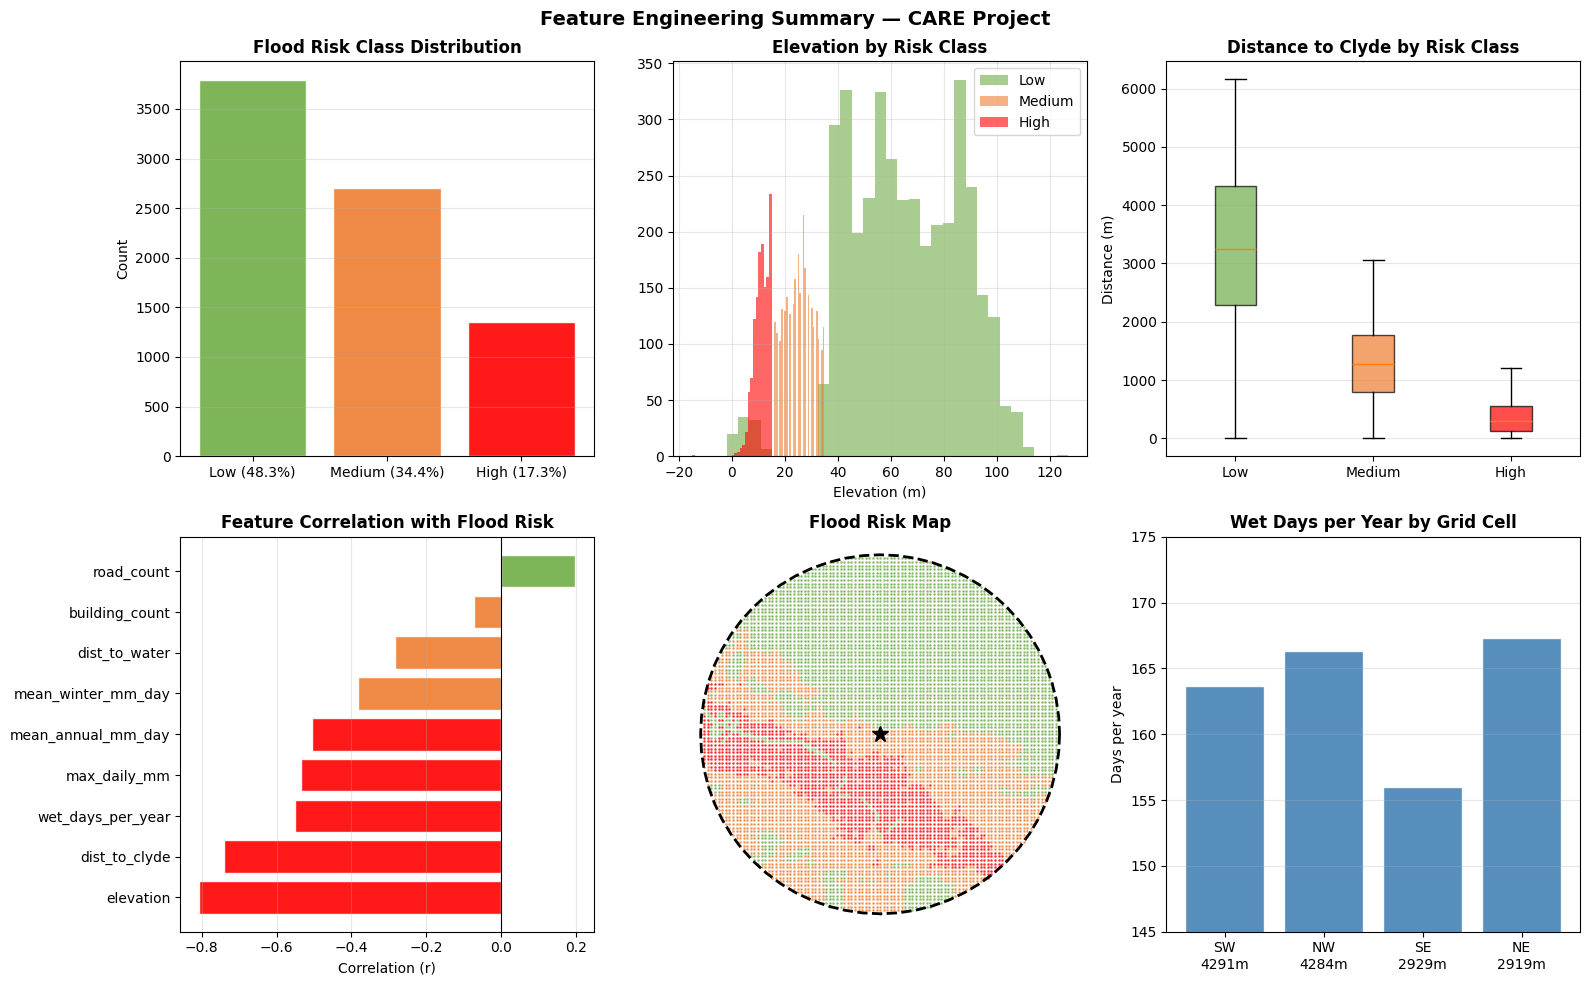

Summary saved!


In [16]:
# ── Step 11: Feature matrix visualisation ───────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# 1. Risk class distribution
colors = ['#70AD47', '#ED7D31', '#FF0000']
labels = ['Low (48.3%)', 'Medium (34.4%)', 'High (17.3%)']
counts = [3790, 2698, 1355]
axes[0,0].bar(labels, counts, color=colors, edgecolor='white', alpha=0.9)
axes[0,0].set_title("Flood Risk Class Distribution", fontweight='bold')
axes[0,0].set_ylabel("Count")
axes[0,0].grid(axis='y', alpha=0.3)

# 2. Elevation distribution by class
for cls, color, name in zip([0,1,2], colors, ['Low','Medium','High']):
    data = feature_matrix[feature_matrix['flood_risk']==cls]['elevation']
    axes[0,1].hist(data, bins=30, alpha=0.6, color=color, label=name)
axes[0,1].set_title("Elevation by Risk Class", fontweight='bold')
axes[0,1].set_xlabel("Elevation (m)")
axes[0,1].legend()
axes[0,1].grid(alpha=0.3)

# 3. Distance to Clyde by class
data_cls = [feature_matrix[feature_matrix['flood_risk']==c]['dist_to_clyde'].values
            for c in [0,1,2]]
bp = axes[0,2].boxplot(data_cls, patch_artist=True)
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[0,2].set_xticklabels(['Low','Medium','High'])
axes[0,2].set_title("Distance to Clyde by Risk Class", fontweight='bold')
axes[0,2].set_ylabel("Distance (m)")
axes[0,2].grid(axis='y', alpha=0.3)

# 4. Correlation bar chart
corr = feature_matrix.corr()['flood_risk'].drop('flood_risk').sort_values()
colors_corr = ['#FF0000' if v < -0.5 else '#ED7D31' if v < 0 else '#70AD47'
               for v in corr.values]
axes[1,0].barh(corr.index, corr.values, color=colors_corr,
               edgecolor='white', alpha=0.9)
axes[1,0].axvline(0, color='black', linewidth=0.8)
axes[1,0].set_title("Feature Correlation with Flood Risk", fontweight='bold')
axes[1,0].set_xlabel("Correlation (r)")
axes[1,0].grid(axis='x', alpha=0.3)

# 5. Risk map
risk_colors = {0:'#70AD47', 1:'#ED7D31', 2:'#FF0000'}
for cls, color in risk_colors.items():
    subset = grid_labelled[grid_labelled['flood_risk']==cls]
    subset.plot(ax=axes[1,1], color=color, markersize=1, alpha=0.6)
uni_buffer.plot(ax=axes[1,1], color='none', edgecolor='black',
                linewidth=2, linestyle='--')
axes[1,1].plot(UNI_X, UNI_Y, marker='*', color='black', markersize=12)
axes[1,1].set_title("Flood Risk Map", fontweight='bold')
axes[1,1].axis('off')

# 6. Rainfall spatial variation
cell_labels = ['SW', 'NW', 'SE', 'NE']
wet_days = feature_matrix.groupby(
    feature_matrix['wet_days_per_year'])['wet_days_per_year'].count()
axes[1,2].bar(['SW\n4291m','NW\n4284m','SE\n2929m','NE\n2919m'],
              [163.7, 166.3, 156.0, 167.3],
              color='steelblue', edgecolor='white', alpha=0.9)
axes[1,2].set_title("Wet Days per Year by Grid Cell", fontweight='bold')
axes[1,2].set_ylabel("Days per year")
axes[1,2].set_ylim(145, 175)
axes[1,2].grid(axis='y', alpha=0.3)

plt.suptitle("Feature Engineering Summary — CARE Project",
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{MAPS_PATH}/feature_engineering_summary.png", dpi=150)
plt.show()
print("Summary saved!")